In [1]:

import os, sys
import tensorflow as tf
import numpy as np
import torch
import matplotlib.pyplot as plt
import sionna
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, PathSolver
from sionna.rt.utils import subcarrier_frequencies

# Enable memory growth
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

import sys, os
sys.path.append(os.path.abspath('..'))

# NOTE: compute_batch_paths / get_ofdm_channel were imported here AND redefined
# again in the next cell. The redefinitions in the next cell are the ones that
# actually get used (Python name shadowing), so the import below is removed to
# avoid the confusing situation where two different implementations share the
# same name and only one of them silently wins.
from GMM.gmtc_em import gmm_em_fit_fullcov, predict_modes


SCENE_DIR = os.path.abspath("POSTECH_scene")
SCENE_XML = os.path.join(SCENE_DIR, "POSTECH.xml")
assert os.path.isfile(SCENE_XML), f"Scene file not found: {SCENE_XML}"


2026-08-19 11:06:29.637052: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
jitc_llvm_init(): LLVM API initialization failed ..


In [2]:

class Config():
    # --- fc: 3.5GHz (5G NR n78 band) ---------------------------------------
    # 8x8=64소자 매시브 MIMO 배열의 공간 채널 딕셔너리(GMM)를 만드는
    # 것이 목적이라 3.5GHz n78 대역(국내 5G 상용 주파수 중 하나)을 유지합니다.
    # ITU 재질 모델(ITURadioMaterial)은 주파수에 따라 유전율/도전율을 계산식으로
    # 산출하므로 2.1GHz든 3.5GHz든 물리적으로 둘 다 유효합니다 — 어떤 fc를 쓰든
    # 반드시 scene.frequency를 안테나 배열(tx_array/rx_array) 생성 "전"에
    # 설정해야 합니다 (배열 소자 간격이 파장 배수로 계산되기 때문). 아래
    # setup_scene_with_positions()에서 이 순서를 지키고 있습니다.
    fc: float = 3.5e9
    scs: float = 30e3
    fft_size: int = 1024
    # 600 subcarriers * 30kHz ≈ 18MHz active BW, 5G NR 20MHz/30kHz numerology의 51 PRB(=612 subcarriers)
    num_active_subcarriers: int = 600

    # --- 안테나 설정 -----------------------------------------------------
    num_bs_ant_rows: int = 8
    num_bs_ant_cols: int = 8
    # UE: 1x1 "dipole" (SISO 수신)
    num_ue_ant_rows: int = 1
    num_ue_ant_cols: int = 1

    num_pos: int = 50
    pos_start: tuple = (50.0, 10.0, 1.5)
    pos_step: tuple = (0.0, 1.0, 0.0) # 1 meter spaced

config = Config()

def setup_scene_with_positions(config, positions):
    scene = load_scene(SCENE_XML)

    # scene.frequency MUST be set before scene.tx_array / scene.rx_array are
    # created, because PlanarArray's vertical_spacing/horizontal_spacing are
    # given in units of wavelength (= c / scene.frequency at creation time).
    # This order was already correct, kept explicit here.
    scene.frequency = config.fc
    # scene.bandwidth only feeds Scene.thermal_noise_power (temperature *
    # k_B * bandwidth); it does NOT affect paths/cfr computation itself. We
    # set it anyway (matching SU_01/SU_02 practice) so the scene is fully
    # self-consistent if thermal noise is ever added later.
    scene.bandwidth = config.fft_size * config.scs

    scene.tx_array = PlanarArray(
        num_rows=config.num_bs_ant_rows,
        num_cols=config.num_bs_ant_cols,
        vertical_spacing=0.5,
        horizontal_spacing=0.5,
        pattern="tr38901",
        polarization="V"
    )

    scene.rx_array = PlanarArray(
        num_rows=config.num_ue_ant_rows,
        num_cols=config.num_ue_ant_cols,
        vertical_spacing=0.5,
        horizontal_spacing=0.5,
        pattern="dipole",
        polarization="V"
    )

    bs = Transmitter("bs", position= [-70, -25, 15])

    if "bs" in scene.transmitters:
        scene.remove("bs")
    scene.add(bs)

    # Remove existing receivers
    for name in list(scene.receivers.keys()):
        scene.remove(name)

    pos_list = []
    # Add multiple receivers for batching
    for i in range(len(positions)):
        pos = positions[i]
        ue = Receiver(f"ue_{i}", position=pos)
        # --- FIXED: this notebook (GMM_static) builds a *static* spatial
        # channel dictionary: every grid point is a separate, motionless UE
        # snapshot, not a single UE moving along a trajectory.
        ue.velocity = [0.0, 0.0, 0.0]
        scene.add(ue)
        pos_list.append(pos)

    pos_tensor = tf.cast(tf.stack(pos_list, axis=0), tf.float32) # [N_pos, 3]
    return scene, bs, None, pos_tensor

def setup_scene(config):
    positions = []
    for i in range(config.num_pos):
        pos = [config.pos_start[0] + i*config.pos_step[0],
               config.pos_start[1] + i*config.pos_step[1],
               config.pos_start[2] + i*config.pos_step[2]]
        positions.append(pos)
    return setup_scene_with_positions(config, np.array(positions))


def compute_batch_paths(scene, max_depth=4):

    # 나머지 인자들은 SU_01/SU_02와 동일한 값을 명시적으로 지정합니다:
    #   - synthetic_array=True: BS가 64소자 어레이이므로 소자쌍마다 개별
    #     레이트레이싱하는 대신(synthetic_array=False) 평면파 가정으로 위상만
    #     보정하는 synthetic array를 사용 (PathSolver의 기본값이기도 함).
    #     이는 대규모 배열에서 표준적으로 쓰이는 방식이며 element spacing
    #     (0.5*wavelength)이 씬의 특징적 크기보다 훨씬 작으므로 평면파 가정이
    #     타당합니다.
    #   - specular_reflection=True, diffuse_reflection=False, refraction=True:
    #     SU_02의 _solve_slot_with_retry()와 동일한 설정.
    #   - seed=42: 재현성을 위해 고정 (PathSolver 기본값과 동일하지만 명시).
    solver = PathSolver()
    paths = solver(
        scene=scene,
        max_depth=max_depth,
        samples_per_src=1_000_000,
        synthetic_array=True,
        los=True,
        specular_reflection=True,
        diffuse_reflection=False,
        refraction=True,
        seed=42,
    )
    return paths

def get_ofdm_channel(paths, config):
    freqs = subcarrier_frequencies(config.fft_size, config.scs)

    cfr = paths.cfr(
        frequencies=freqs,
        sampling_frequency=config.scs,
        num_time_steps=1,
        # --- normalize_delays=False (intentional, differs from SU_01/02) ---
        # SU_01/SU_02는 CIR/CFR을 "링크별" 형태(멀티패스 모양)로 시각화/저장
        #하는 것이 목적이라 normalize_delays=True로 절대 전파 지연(=BS-UE
        # 거리에 비례하는 위상)을 제거합니다. 반면 이 노트북은 그리드의
        # "위치별" 채널 상태를 서로 구분하는 공간 딕셔너리를 만드는 것이
        # 목적이므로, 위치마다 다른 절대 지연(=거리 정보)이 오히려 클러스터를
        # 구분하는 유용한 정보입니다. 그래서 정규화하지 않습니다.
        normalize_delays=False,
        normalize=True,
        out_type="tf"
    )

    # cfr shape: [num_rx=N_pos, num_rx_ant=1, num_tx=1, num_tx_ant=64, num_time_steps=1, num_subcarriers]
    # Extract all receivers, active subcarriers, and time_step 0
    h_freq = cfr[..., 0, :config.num_active_subcarriers]

    # Reshape to [N_pos, N_tx_ant, active_subcarriers]
    num_rx = tf.shape(h_freq)[0]
    h_reshaped = tf.reshape(h_freq, [num_rx, config.num_bs_ant_rows*config.num_bs_ant_cols, config.num_active_subcarriers])

    # Transpose to [N_pos, N_sub, N_tx]
    h_transposed = tf.transpose(h_reshaped, [0, 2, 1])
    return h_transposed

def compute_spatial_covariance(h_tensor):
    # h_tensor: [N_pos, N_sub, N_tx]
    # expand to [N_pos, N_sub, N_tx, 1]
    h_exp = tf.expand_dims(h_tensor, axis=-1)

    # Outer product for each position and subcarrier: h * h^H -> [N_pos, N_sub, N_tx, N_tx]
    R_per_pos = tf.matmul(h_exp, h_exp, adjoint_b=True)

    # NOTE: this averages the covariance across DIFFERENT spatial positions
    # (N_pos), which mixes together channel statistics from geographically
    # distinct, non-stationary locations into a single matrix. That is not a
    # meaningful "spatial covariance" for any one location - it is currently
    # unused by the GMM training below, but if you do use it, average over
    # subcarriers (and/or time snapshots at a *single* position) instead of
    # averaging across the grid:
    #   R_mean_per_position = tf.reduce_mean(R_per_pos, axis=1)  # -> [N_pos, N_tx, N_tx]
    R_mean = tf.reduce_mean(R_per_pos, axis=0)

    return R_mean


In [3]:

# Cell V: 파라미터 검증
# 목적: 실제 시뮬레이션에 사용될 config 값과 로드된 scene의 재질/치수가
# 서로 일관적인지 실행 전에 눈으로 확인합니다.

print("="*70)
print("SIMULATION PARAMETERS")
print("="*70)
param_names = ["fc", "scs", "fft_size", "num_active_subcarriers",
               "num_bs_ant_rows", "num_bs_ant_cols",
               "num_ue_ant_rows", "num_ue_ant_cols",
               "num_pos", "pos_start", "pos_step"]
for name in param_names:
    print(f"- {name}: {getattr(config, name)}")

# --- 파생값 검증 -------------------------------------------------------
total_bw = config.fft_size * config.scs
active_bw = config.num_active_subcarriers * config.scs
wavelength = 3e8 / config.fc
elem_spacing_m = 0.5 * wavelength

print("\n" + "="*70)
print("DERIVED / SANITY CHECKS")
print("="*70)
print(f"- Total sampling bandwidth (fft_size * scs): {total_bw/1e6:.2f} MHz")
print(f"- Active bandwidth (num_active_subcarriers * scs): {active_bw/1e6:.2f} MHz")
assert config.num_active_subcarriers <= config.fft_size, \
    "num_active_subcarriers must not exceed fft_size!"
print(f"- Wavelength @ fc: {wavelength*100:.2f} cm")
print(f"- Antenna element spacing (0.5*lambda): {elem_spacing_m*100:.2f} cm")
print(f"- BS array physical aperture (approx): "
      f"{config.num_bs_ant_rows*elem_spacing_m:.2f} m (vert) x "
      f"{config.num_bs_ant_cols*elem_spacing_m:.2f} m (horiz)")
print(f"- Total BS antenna elements: {config.num_bs_ant_rows*config.num_bs_ant_cols}")
print(f"- Total UE antenna elements: {config.num_ue_ant_rows*config.num_ue_ant_cols}")

# --- Scene / material 검증 (씬 오브젝트별 재질 나열) ---
validation_scene = load_scene(SCENE_XML)
validation_scene.frequency = config.fc
print("\n" + "="*70)
print(f"SCENE OBJECTS & RADIO MATERIALS (scene.frequency = {validation_scene.frequency})")
print("="*70)
for i, obj in enumerate(validation_scene.objects.values()):
    print(f"{obj.name} : {obj.radio_material.name}")
    if i >= 14:
        remaining = len(validation_scene.objects) - (i + 1)
        if remaining > 0:
            print(f"... ({remaining} more objects)")
        break

bbox = validation_scene.mi_scene.bbox()
print(f"\nScene bounding box: x=[{bbox.min[0]:.1f}, {bbox.max[0]:.1f}], "
      f"y=[{bbox.min[1]:.1f}, {bbox.max[1]:.1f}], z=[{bbox.min[2]:.1f}, {bbox.max[2]:.1f}]")

# --- BS 위치가 씬 안에, 그리고 지붕선보다 위(가시성 확보)에 있는지 확인 ---
bs_check_pos = [-70, -25, 15]  # setup_scene_with_positions()의 bs 위치와 일치해야 함
in_bounds = (bbox.min[0] <= bs_check_pos[0] <= bbox.max[0] and
             bbox.min[1] <= bs_check_pos[1] <= bbox.max[1])
print(f"\nBS position {bs_check_pos}:")
print(f"  - inside scene x/y bounds: {in_bounds}")
print(f"  - height {bs_check_pos[2]} m vs scene max z {bbox.max[2]:.1f} m "
      f"({'above' if bs_check_pos[2] > bbox.max[2] else 'BELOW rooftop level - check for LOS blockage!'})")

# --- 1x1 dipole vs 8x8 tr38901 배열이 실제로 scene에 적용됐는지 확인 ---
validation_scene.tx_array = PlanarArray(num_rows=config.num_bs_ant_rows, num_cols=config.num_bs_ant_cols,
                                         vertical_spacing=0.5, horizontal_spacing=0.5,
                                         pattern="tr38901", polarization="V")
validation_scene.rx_array = PlanarArray(num_rows=config.num_ue_ant_rows, num_cols=config.num_ue_ant_cols,
                                         vertical_spacing=0.5, horizontal_spacing=0.5,
                                         pattern="dipole", polarization="V")
print(f"\ntx_array: {config.num_bs_ant_rows}x{config.num_bs_ant_cols} "
      f"(array_size={validation_scene.tx_array.array_size}, num_ant={validation_scene.tx_array.num_ant}), "
      f"pattern={validation_scene.tx_array.antenna_pattern}")
print(f"rx_array: {config.num_ue_ant_rows}x{config.num_ue_ant_cols} "
      f"(array_size={validation_scene.rx_array.array_size}, num_ant={validation_scene.rx_array.num_ant}), "
      f"pattern={validation_scene.rx_array.antenna_pattern}")


SIMULATION PARAMETERS
- fc: 3500000000.0
- scs: 30000.0
- fft_size: 1024
- num_active_subcarriers: 600
- num_bs_ant_rows: 8
- num_bs_ant_cols: 8
- num_ue_ant_rows: 1
- num_ue_ant_cols: 1
- num_pos: 50
- pos_start: (50.0, 10.0, 1.5)
- pos_step: (0.0, 1.0, 0.0)

DERIVED / SANITY CHECKS
- Total sampling bandwidth (fft_size * scs): 30.72 MHz
- Active bandwidth (num_active_subcarriers * scs): 18.00 MHz
- Wavelength @ fc: 8.57 cm
- Antenna element spacing (0.5*lambda): 4.29 cm
- BS array physical aperture (approx): 0.34 m (vert) x 0.34 m (horiz)
- Total BS antenna elements: 64
- Total UE antenna elements: 1

SCENE OBJECTS & RADIO MATERIALS (scene.frequency = [3.5e+09])
no-name-1 : itu_brick
no-name-2 : itu_concrete
elm__3 : itu_very_dry_ground

Scene bounding box: x=[-215.0, 245.0], y=[-245.0, 215.0], z=[0.0, 20.7]

BS position [-70, -25, 15]:
  - inside scene x/y bounds: True
  - height 15 m vs scene max z 20.7 m (BELOW rooftop level - check for LOS blockage!)

tx_array: 8x8 (array_size=64,

In [4]:

# Cell A1: Dense spatial grid generation
GRID_NX, GRID_NY = 60, 60 

probe_scene = load_scene(SCENE_XML)
bbox = probe_scene.mi_scene.bbox()
margin = 5.0  # meters, keep grid points away from the scene edge
x_min, x_max = bbox.min[0] + margin, bbox.max[0] - margin
y_min, y_max = bbox.min[1] + margin, bbox.max[1] - margin
print(f"Scene bounding box: x=[{bbox.min[0]:.1f}, {bbox.max[0]:.1f}], "
      f"y=[{bbox.min[1]:.1f}, {bbox.max[1]:.1f}], z=[{bbox.min[2]:.1f}, {bbox.max[2]:.1f}]")

x_range = np.linspace(x_min, x_max, GRID_NX)
y_range = np.linspace(y_min, y_max, GRID_NY)
z_fixed = 1.5  # pedestrian UE height

grid_x, grid_y = np.meshgrid(x_range, y_range)

grid_positions = np.stack(
    [grid_x.ravel(), grid_y.ravel(), np.full(grid_x.size, z_fixed)], axis=-1
)
print("Grid map positions:", grid_positions.shape)



Scene bounding box: x=[-215.0, 245.0], y=[-245.0, 215.0], z=[0.0, 20.7]
Grid map positions: (3600, 3)


In [5]:

# Cell A2: Channel extraction for grid
scene_map, bs_map, _, _ = setup_scene_with_positions(config, grid_positions)
paths_map = compute_batch_paths(scene_map, max_depth=2)
h_grid = get_ofdm_channel(paths_map, config)
print("Grid channel shape:", h_grid.shape)
scene_map.preview(paths=paths_map)


energy_per_pos = tf.reduce_sum(tf.abs(h_grid) ** 2, axis=[1, 2])  # [N_grid]
invalid_mask = tf.math.is_nan(energy_per_pos) | tf.math.is_inf(energy_per_pos) | (energy_per_pos < 1e-12)
invalid_np = invalid_mask.numpy()
print(f"Invalid / no-coverage grid points: {invalid_np.sum()} / {invalid_np.shape[0]}")


I0000 00:00:1787137594.063988 1296291 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46168 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:81:00.0, compute capability: 8.9
I0000 00:00:1787137594.065406 1296291 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 46548 MB memory:  -> device: 1, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:c1:00.0, compute capability: 8.9
I0000 00:00:1787137594.066777 1296291 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 46548 MB memory:  -> device: 2, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:c2:00.0, compute capability: 8.9


Grid channel shape: (3600, 600, 64)


Invalid / no-coverage grid points: 1228 / 3600


a_grid.shape   : (3600, 1, 1, 64, 11, 1)
tau_grid.shape : (3600, 1, 11)


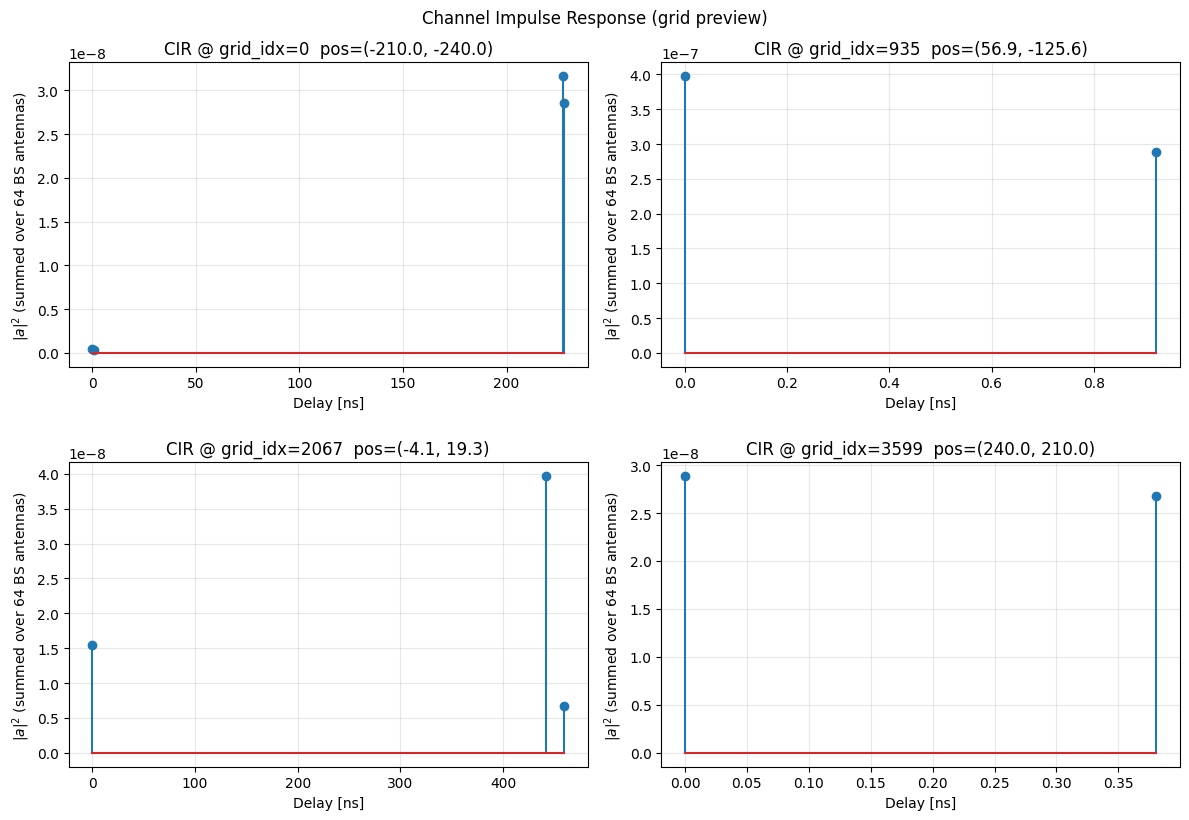

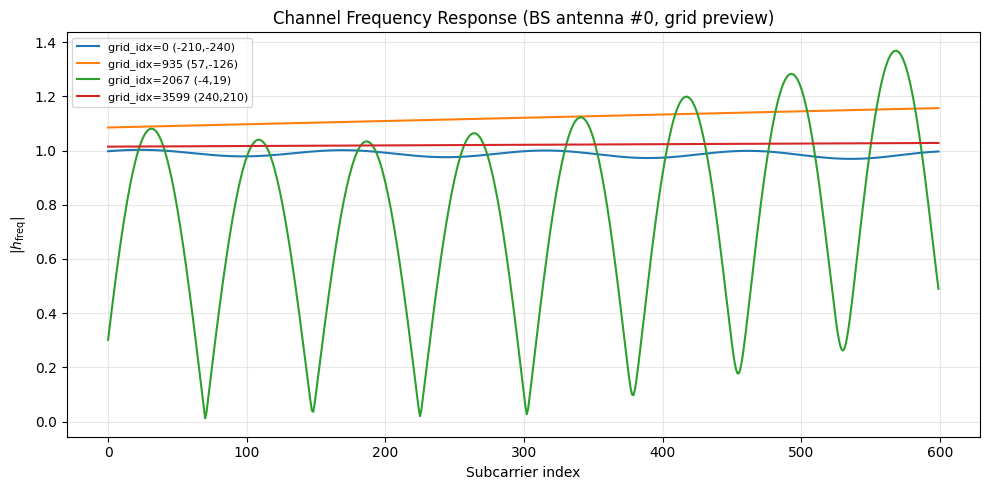

In [6]:

# Cell A2-1: CIR / CFR 결과 시각화 (SU_01 Cell 16-19, SU_02 Cell 5-6 스타일)
# 목적: get_ofdm_channel()이 만들어낸 h_grid가 실제로 그럴듯한 값인지, 그리고
# path solver가 반환한 raw CIR도 물리적으로 말이 되는지 눈으로 확인합니다.

# --- (1) CIR: a, tau = paths.cir() -----------------------------------------
a_grid, tau_grid = paths_map.cir(out_type="numpy")
print(f"a_grid.shape   : {a_grid.shape}")   # 기대: [num_rx, rx_ant, num_tx, tx_ant, num_paths, num_time_steps]
print(f"tau_grid.shape : {tau_grid.shape}")

# BS(tx) 안테나(64소자) 축으로 파워를 합산 -> [num_rx, num_paths] 형태로 축소
# (SU_01 Cell 17과 동일한 방식: a_abs_square = sum over tx antennas)
a_abs_sq = np.abs(a_grid) ** 2
tx_ant_axis = 3 if a_abs_sq.ndim == 6 else None
if tx_ant_axis is not None:
    a_abs_sq = a_abs_sq.sum(axis=tx_ant_axis)   # -> [num_rx, rx_ant, num_tx, num_paths, num_time_steps]

# 시각화할 그리드 위치 4개 선택: invalid_np가 이미 위에서 계산되어 있으므로
# 유효한 (커버리지가 있는) 위치들 중에서 고릅니다.
valid_preview_idx = np.where(~invalid_np)[0]
n_preview = min(4, len(valid_preview_idx))
preview_idx = valid_preview_idx[np.linspace(0, len(valid_preview_idx) - 1, n_preview, dtype=int)] \
    if n_preview > 0 else np.array([], dtype=int)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
axes = axes.flatten()
for k in range(4):
    ax = axes[k]
    if k >= n_preview:
        ax.axis("off")
        continue
    pos_idx = int(preview_idx[k])
    a_tmp = np.squeeze(a_abs_sq[pos_idx])          # -> [num_paths] (time_steps=1도 squeeze됨)
    tau_ns = np.squeeze(tau_grid[pos_idx]) * 1e9    # delay in ns

    valid_paths = tau_ns >= 0.0
    a_tmp = a_tmp[valid_paths] if a_tmp.ndim == 1 else a_tmp
    tau_ns = tau_ns[valid_paths] if tau_ns.ndim == 1 else tau_ns

    pos_xy = grid_positions[pos_idx, :2]
    ax.stem(tau_ns, a_tmp)
    ax.set_title(f"CIR @ grid_idx={pos_idx}  pos=({pos_xy[0]:.1f}, {pos_xy[1]:.1f})")
    ax.set_xlabel("Delay [ns]")
    ax.set_ylabel(r"$|a|^2$ (summed over 64 BS antennas)")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.suptitle("Channel Impulse Response (grid preview)", y=1.02)
plt.show()

# --- (2) CFR: 이미 get_ofdm_channel()에서 계산된 h_grid[N_pos, N_sub, N_tx] 사용 ---
# (SU_01 Cell 19와 동일한 개념: |H(f)| vs subcarrier index)
tx_ant_plot = 0  # 64개 BS 안테나 소자 중 대표로 1개만 표시
fig, ax = plt.subplots(figsize=(10, 5))
for k in range(n_preview):
    pos_idx = int(preview_idx[k])
    pos_xy = grid_positions[pos_idx, :2]
    ax.plot(np.abs(h_grid[pos_idx, :, tx_ant_plot].numpy()),
            label=f"grid_idx={pos_idx} ({pos_xy[0]:.0f},{pos_xy[1]:.0f})")
ax.set_xlabel("Subcarrier index")
ax.set_ylabel(r"|$h_\text{freq}$|")
ax.set_title(f"Channel Frequency Response (BS antenna #{tx_ant_plot}, grid preview)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [7]:

# Cell A3: Train GMM on grid data
# --- CHANGED: train only on positions with a valid (non-blocked) channel.
valid_idx = np.where(~invalid_np)[0]
h_grid_valid = tf.gather(h_grid, valid_idx, axis=0)  # [N_valid, N_sub, N_tx]

N_grid, N_sub, N_tx = h_grid.shape
sub_stride = 10
sub_idx = tf.range(0, N_sub, sub_stride)
h_map_train = tf.reshape(tf.gather(h_grid_valid, sub_idx, axis=1), [-1, N_tx])

h_map_real = tf.concat([tf.math.real(h_map_train), tf.math.imag(h_map_train)], axis=-1)
Xt_map_raw = torch.from_numpy(h_map_real.numpy()).to(torch.float32)
# Safety net only (should be a no-op now that invalid points are excluded above):
# also clamp any stray +-inf, not just NaN.
Xt_map = torch.nan_to_num(Xt_map_raw, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Training GMM with {Xt_map.shape[0]} samples (from {len(valid_idx)}/{N_grid} valid positions)...")
print(f"Contains NaN: {torch.isnan(Xt_map).any().item()}")
print(f"Max val: {Xt_map.max().item()}, Min val: {Xt_map.min().item()}")
K = 8
params_map = gmm_em_fit_fullcov(Xt_map, K=K, num_iter=100, eps=1e-5, seed=42, verbose=True)

import os
os.makedirs("output", exist_ok=True)
torch.save(params_map, f"output/gmm_spatial_dictionary_K{K}.pt")


Training GMM with 142320 samples (from 2372/3600 valid positions)...
Contains NaN: False
Max val: 2.6952545642852783, Min val: -2.647047519683838
[EM] it=000 ll=23420120.000
[EM] it=001 ll=35903368.000 dLL=12483248.000
[EM] it=002 ll=48918736.000 dLL=13015368.000
[EM] it=003 ll=52976732.000 dLL=4057996.000
[EM] it=004 ll=54021344.000 dLL=1044612.000
[EM] it=005 ll=54481776.000 dLL=460432.000
[EM] it=006 ll=54936000.000 dLL=454224.000
[EM] it=007 ll=55205660.000 dLL=269660.000
[EM] it=008 ll=55406348.000 dLL=200688.000
[EM] it=009 ll=55548608.000 dLL=142260.000
[EM] it=010 ll=55634884.000 dLL=86276.000
[EM] it=011 ll=55669544.000 dLL=34660.000
[EM] it=012 ll=55687176.000 dLL=17632.000
[EM] it=013 ll=55709008.000 dLL=21832.000
[EM] it=014 ll=55745616.000 dLL=36608.000
[EM] it=015 ll=55772344.000 dLL=26728.000
[EM] it=016 ll=55775192.000 dLL=2848.000
[EM] it=017 ll=55776880.000 dLL=1688.000
[EM] it=018 ll=55778928.000 dLL=2048.000
[EM] it=019 ll=55778452.000 dLL=-476.000
[EM] it=020 ll=55

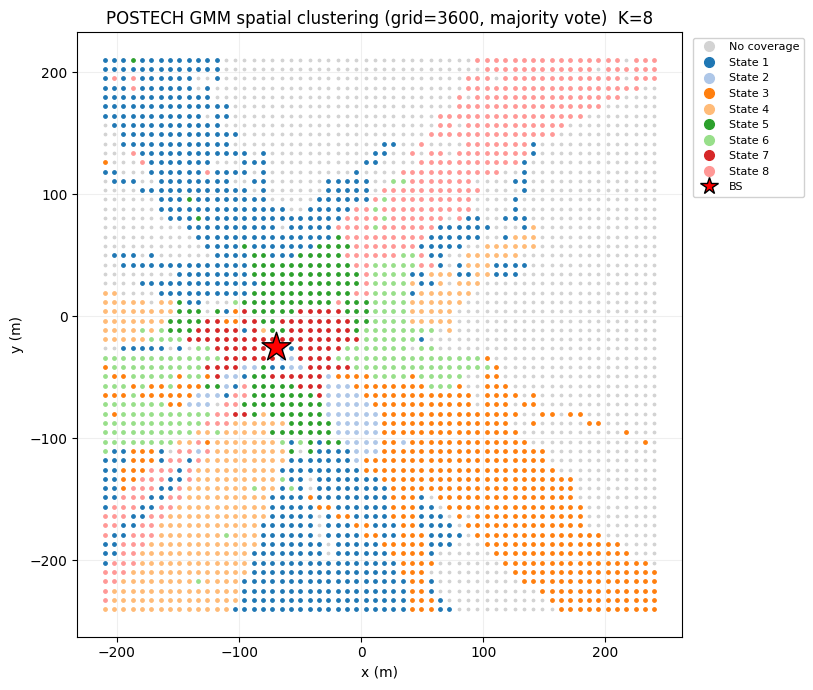

In [8]:

# Cell A4: Spatial EM Map visualization (ASU run_em.py 스타일)
from matplotlib.lines import Line2D

sub_stride = 10
sub_idx = tf.range(0, N_sub, sub_stride)

h_grid_sub = tf.gather(h_grid_valid, sub_idx, axis=1)  # [N_valid, N_sub_sub, N_tx]
N_sub_sub = h_grid_sub.shape[1]

h_grid_sub_real = tf.concat([tf.math.real(h_grid_sub), tf.math.imag(h_grid_sub)], axis=-1)
h_grid_sub_torch = torch.nan_to_num(
    torch.from_numpy(h_grid_sub_real.numpy()).to(torch.float32),
    nan=0.0, posinf=0.0, neginf=0.0
)

N_valid = h_grid_sub_torch.shape[0]
c_hat_valid_all = np.zeros((N_valid, N_sub_sub), dtype=int)
for i in range(N_sub_sub):
    c, _ = predict_modes(h_grid_sub_torch[:, i, :], params_map)
    c_hat_valid_all[:, i] = c.numpy()

from scipy.stats import mode
c_hat_valid, _ = mode(c_hat_valid_all, axis=1, keepdims=False)  # majority vote, [N_valid]

# Scatter back onto the full grid: invalid positions get label -1 ("no coverage")
c_hat_grid = np.full(N_grid, -1, dtype=int)
c_hat_grid[valid_idx] = c_hat_valid

bs_pos = np.array(bs_map.position)  # actual BS location in the POSTECH scene (see Cell setup)

cmap = plt.get_cmap("tab20")
fig, ax = plt.subplots(figsize=(8.5, 7))
handles = []

# "No coverage" points (blocked / no valid path) in light gray, like run_em.py's pos_nouser
m_invalid = (c_hat_grid == -1)
if m_invalid.sum():
    ax.scatter(grid_positions[m_invalid, 0], grid_positions[m_invalid, 1], s=3, c="lightgray")
    handles.append(Line2D([], [], marker="o", ls="", ms=7, color="lightgray", label="No coverage"))

for k in range(K):
    m = (c_hat_grid == k)
    if m.sum():
        ax.scatter(grid_positions[m, 0], grid_positions[m, 1], s=6, color=cmap(k % 20))
        handles.append(Line2D([], [], marker="o", ls="", ms=7, color=cmap(k % 20), label=f"State {k+1}"))

ax.scatter(bs_pos[0], bs_pos[1], marker="*", s=480, c="red", edgecolor="k", zorder=5)
handles.append(Line2D([], [], marker="*", ls="", ms=13, color="red", mec="k", label="BS"))

ax.set(title=f"POSTECH GMM spatial clustering (grid={N_grid}, majority vote)  K={K}",
       xlabel="x (m)", ylabel="y (m)")
ax.set_aspect("equal")
ax.grid(alpha=.2)
ax.legend(handles=handles, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0), framealpha=.9)
plt.tight_layout()
plt.savefig(f"output/em_map_spatial_K{K}.png", dpi=120)
plt.show()
